# Experimento 4 — Identificação de Perfis Afetivos

## Objetivo

Este notebook tem como objetivo transformar os fatores latentes obtidos no Experimento 3 em **tipologias de indivíduos**, utilizando técnicas de análise de clusters e procedimentos de validação estatística.

Diferentemente do Experimento 3, cujo foco foi identificar dimensões latentes do construto estudado, o presente experimento busca responder a uma nova pergunta de pesquisa:

> Existem perfis distintos de indivíduos organizados segundo essas dimensões afetivas?

A unidade de análise permanece sendo o indivíduo.

---

## Arquivo de entrada

Este notebook deve iniciar exclusivamente pela leitura do arquivo:

```
dados/processados/afe_second_order_scores.parquet
```

Esse arquivo contém:

- identificação dos indivíduos;
- país;
- ano;
- indicadores derivados do WVS;
- oito fatores de primeira ordem;
- três fatores de segunda ordem produzidos no Experimento 3.

Nenhum cálculo da etapa anterior deverá ser reexecutado.

---

## Procedimentos previstos

Este notebook executará as seguintes etapas:

1. Padronização dos fatores de segunda ordem.

2. Determinação do número ótimo de clusters.

3. Identificação dos perfis afetivos utilizando K-Means.

4. Caracterização dos centroides.

5. Estimativa da frequência dos perfis.

6. Avaliação da coesão interna.

7. Visualização bidimensional por PCA.

8. Associação entre perfis e países.

9. Teste do qui-quadrado.

10. Estimativa do V de Cramér.

11. Cálculo dos resíduos padronizados.

12. Exportação completa das tabelas e das bases produzidas.

---

## Produtos esperados

Ao término da execução deverão existir:

### Bases

```
dados/processados/

experimento4_perfis.parquet

experimento4_coords_pca.parquet
```

### Resultados

```
resultados/experimento4/
```

contendo tabelas intermediárias em formato Excel.

### Figuras

```
figuras/experimento4/
```

---

## Observações metodológicas

Este notebook tem caráter exclusivamente exploratório e descritivo.

Nenhuma variável contextual (V-Dem ou V-Party) será utilizada.

Toda a análise permanece restrita aos dados individuais do World Values Survey.

As análises contextuais serão realizadas apenas em notebooks posteriores.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path(r"C:\Users\tmaci\Documents\Doutorado_Populismo")
dados = BASE / "dados" / "processados"

afe = pd.read_parquet(dados / "afe_second_order_scores.parquet")

print(afe.shape)
afe.head()

(24053, 60)


,COUNTRY_ALPHA,S020,S002VS,S018,E033,national_pride,willing_to_fight,grandiosity,reject_different_race,reject_immigrants,...,efa8_political_action,efa8_outgroup_hostility,efa8_social_outgroup_distrust,efa8_moral_political_authoritarianism,efa8_political_interest,efa8_coercive_institutional_trust,efa8_symbolic_nationalism,sof1_authoritarian_order_integration,sof2_authoritarian_exclusion,sof3_political_engagement
1030,ARG,2017,7,0.997009,5.0,1.0,1.0,1.0,0.0,0.0,...,-0.492103,-0.535936,0.902108,-1.084125,-1.282782,-0.199980,0.480398,0.458803,-0.324998,-1.154615
1031,ARG,2017,7,0.997009,NaN,1.0,0.0,0.5,0.0,0.0,...,-0.417502,-0.214594,1.092693,0.100003,-1.021864,-1.589763,-0.497288,1.148716,0.562466,-1.149978
1032,ARG,2017,7,0.997009,8.0,1.0,0.0,0.5,0.0,0.0,...,-0.453429,-0.039959,1.064496,0.569578,-1.211807,0.520844,0.381148,-0.054325,0.755208,-0.754373
1033,ARG,2017,7,0.997009,5.0,1.0,1.0,1.0,0.0,0.0,...,-0.382268,-0.911728,0.805517,1.526403,-1.251189,0.017916,0.148829,0.013801,1.279460,-1.001872
1034,ARG,2017,7,0.997009,NaN,1.0,0.0,0.5,0.0,0.0,...,-0.456399,-0.543081,-1.133260,-0.499333,-1.075221,0.559327,0.199433,-0.649466,-0.721972,-0.120746


In [2]:
from sklearn.preprocessing import StandardScaler

cluster_vars = [
    "sof1_authoritarian_order_integration",
    "sof2_authoritarian_exclusion",
    "sof3_political_engagement"
]

X = afe[cluster_vars].copy()

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=cluster_vars,
    index=afe.index
)

print(X_scaled.describe().round(3))

       sof1_authoritarian_order_integration  sof2_authoritarian_exclusion  \
count                             24053.000                     24053.000   
mean                                  0.000                         0.000   
std                                   1.000                         1.000   
min                                  -3.338                        -1.892   
25%                                  -0.703                        -0.812   
50%                                   0.031                        -0.090   
75%                                   0.724                         0.720   
max                                   2.572                         2.800   

       sof3_political_engagement  
count                  24053.000  
mean                      -0.000  
std                        1.000  
min                       -3.395  
25%                       -0.672  
50%                        0.106  
75%                        0.731  
max                       

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

import pandas as pd

resultados = []

for k in range(2, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    grupos = modelo.fit_predict(X_scaled)

    resultados.append({
        "k": k,
        "Inertia": modelo.inertia_,
        "Silhouette": silhouette_score(X_scaled, grupos),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, grupos),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, grupos)
    })

criterios = pd.DataFrame(resultados)

criterios

,k,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,42184.219169,0.366551,17089.907731,1.080121
1,3,32384.724393,0.303284,14769.125386,1.155742
2,4,27207.933436,0.281015,13244.084874,1.133340
3,5,23693.933231,0.262426,12297.575774,1.091307
4,6,21369.924655,0.245426,11430.417682,1.158672
5,7,19393.203957,0.247460,10904.388783,1.186156
6,8,17754.414000,0.247979,10525.866387,1.105908
7,9,16452.144544,0.249070,10176.709184,1.073113
8,10,15433.704947,0.242456,9818.794334,1.078676


In [4]:
from sklearn.cluster import KMeans

clusters = {}

for k in [2, 3, 4]:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    afe[f"cluster_{k}"] = km.fit_predict(X_scaled)
    clusters[k] = km.cluster_centers_

print("Clusters criados.")

afe[[
    "cluster_2",
    "cluster_3",
    "cluster_4"
]].head()

Clusters criados.


,cluster_2,cluster_3,cluster_4
1030,0,2,3
1031,0,2,3
1032,0,2,2
1033,0,2,2
1034,1,1,1


In [5]:
# ============================================================
# Centroides dos clusters (k = 2, 3 e 4)
# ============================================================

from sklearn.cluster import KMeans

for k in [2, 3, 4]:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    km.fit(X_scaled)

    centroides = pd.DataFrame(
        km.cluster_centers_,
        columns=cluster_vars
    )

    centroides.index = [f"Cluster {i}" for i in range(k)]

    print("\n")
    print("=" * 60)
    print(f"CENTROIDES - k = {k}")
    print("=" * 60)

    display(centroides.round(3))



CENTROIDES - k = 2


,sof1_authoritarian_order_integration,sof2_authoritarian_exclusion,sof3_political_engagement
Cluster 0,-0.606,0.926,-0.809
Cluster 1,0.402,-0.614,0.537




CENTROIDES - k = 3


,sof1_authoritarian_order_integration,sof2_authoritarian_exclusion,sof3_political_engagement
Cluster 0,0.816,-0.745,0.452
Cluster 1,-0.780,-0.005,0.486
Cluster 2,-0.405,1.125,-1.190




CENTROIDES - k = 4


,sof1_authoritarian_order_integration,sof2_authoritarian_exclusion,sof3_political_engagement
Cluster 0,0.762,-0.957,0.736
Cluster 1,-0.938,0.009,0.554
Cluster 2,-0.709,1.328,-1.293
Cluster 3,0.540,0.122,-0.422


In [6]:
# ============================================================
# Distribuição dos clusters (k = 3)
# ============================================================

freq_clusters = (
    afe["cluster_3"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="N")
)

freq_clusters["Percentual"] = (
    100 * freq_clusters["N"] / freq_clusters["N"].sum()
).round(2)

freq_clusters

,Cluster,N,Percentual
0,0,10178,42.31
1,1,7080,29.43
2,2,6795,28.25


In [7]:
perfil_clusters = (
    afe
    .groupby("cluster_3")[cluster_vars]
    .mean()
    .round(3)
)

perfil_clusters

,sof1_authoritarian_order_integration,sof2_authoritarian_exclusion,sof3_political_engagement
cluster_3,,,
0,0.727,-0.679,0.380
1,-0.698,-0.007,0.413
2,-0.362,1.025,-1.001


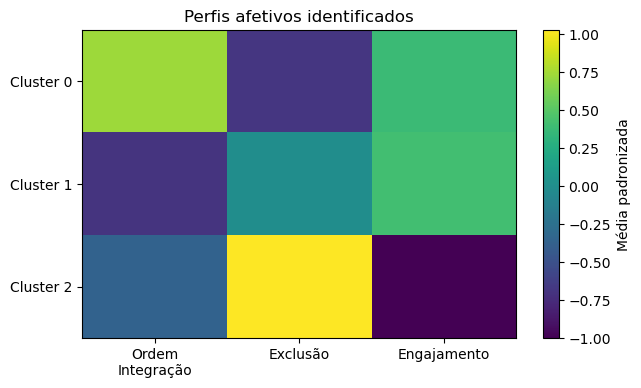

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.imshow(
    perfil_clusters.values,
    aspect="auto"
)

plt.xticks(
    range(len(cluster_vars)),
    [
        "Ordem\nIntegração",
        "Exclusão",
        "Engajamento"
    ]
)

plt.yticks(
    range(3),
    [
        "Cluster 0",
        "Cluster 1",
        "Cluster 2"
    ]
)

plt.colorbar(label="Média padronizada")

plt.title("Perfis afetivos identificados")

plt.show()

In [9]:
pais_cluster = pd.crosstab(
    afe["COUNTRY_ALPHA"],
    afe["cluster_3"],
    normalize="index"
) * 100

pais_cluster = pais_cluster.round(1)

pais_cluster

cluster_3,0,1,2
COUNTRY_ALPHA,,,
ARG,36.7,35.2,28.1
BOL,63.5,30.6,5.9
BRA,46.9,31.3,21.9
CAN,6.4,19.5,74.1
CHL,49.9,35.6,14.5
COL,52.8,30.8,16.4
ECU,50.7,45.8,3.5
GTM,54.1,32.5,13.4
MEX,67.1,27.9,4.9


In [10]:
ano_cluster = pd.crosstab(
    afe["S020"],
    afe["cluster_3"],
    normalize="index"
) * 100

ano_cluster.round(1)

cluster_3,0,1,2
S020,,,
2017,34.0,31.4,34.6
2018,56.4,31.1,12.6
2020,26.2,24.5,49.3
2021,67.5,22.0,10.5
2022,26.6,43.0,30.4


In [11]:
criterios.to_excel(
    BASE / "resultados" / "Tabela_4_1_Criterios_Clusters.xlsx",
    index=False
)

In [12]:
freq_clusters = (
    afe["cluster_3"]
    .value_counts()
    .sort_index()
    .rename_axis("Perfil")
    .reset_index(name="N")
)

freq_clusters["Percentual"] = (
    100 * freq_clusters["N"] / freq_clusters["N"].sum()
).round(2)

freq_clusters.to_excel(
    BASE/"resultados"/"Tabela_4_2_Frequencia_Perfis.xlsx",
    index=False
)

freq_clusters

,Perfil,N,Percentual
0,0,10178,42.31
1,1,7080,29.43
2,2,6795,28.25


In [13]:
perfil_clusters["Perfil sugerido"] = [
    "Institucional-Participativo",
    "Contestatório-Engajado",
    "Excludente-Desengajado"
]

perfil_clusters.to_excel(
    BASE/"resultados"/"Tabela_4_3_Centroides.xlsx"
)

perfil_clusters

,sof1_authoritarian_order_integration,sof2_authoritarian_exclusion,sof3_political_engagement,Perfil sugerido
cluster_3,,,,
0,0.727,-0.679,0.380,Institucional-Participativo
1,-0.698,-0.007,0.413,Contestatório-Engajado
2,-0.362,1.025,-1.001,Excludente-Desengajado


In [14]:
from scipy.spatial.distance import pdist, squareform

distancias = pd.DataFrame(
    squareform(
        pdist(perfil_clusters.iloc[:,0:3])
    ),
    index=perfil_clusters["Perfil sugerido"],
    columns=perfil_clusters["Perfil sugerido"]
)

distancias.round(3)

Perfil sugerido,Institucional-Participativo,Contestatório-Engajado,Excludente-Desengajado
Perfil sugerido,,,
Institucional-Participativo,0.000,1.576,2.449
Contestatório-Engajado,1.576,0.000,1.783
Excludente-Desengajado,2.449,1.783,0.000


In [15]:
distancias.to_excel(
    BASE/"resultados"/"Tabela_4_4_Distancias_Perfis.xlsx"
)

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

coords = pca.fit_transform(X_scaled)

coords = pd.DataFrame(
    coords,
    columns=["PC1","PC2"],
    index=afe.index
)

coords["Perfil"] = afe["cluster_3"]


In [17]:
coords.groupby("Perfil")[["PC1","PC2"]].mean().round(3)

,PC1,PC2
Perfil,,
0,-1.133,0.373
1,0.059,-0.921
2,1.635,0.401


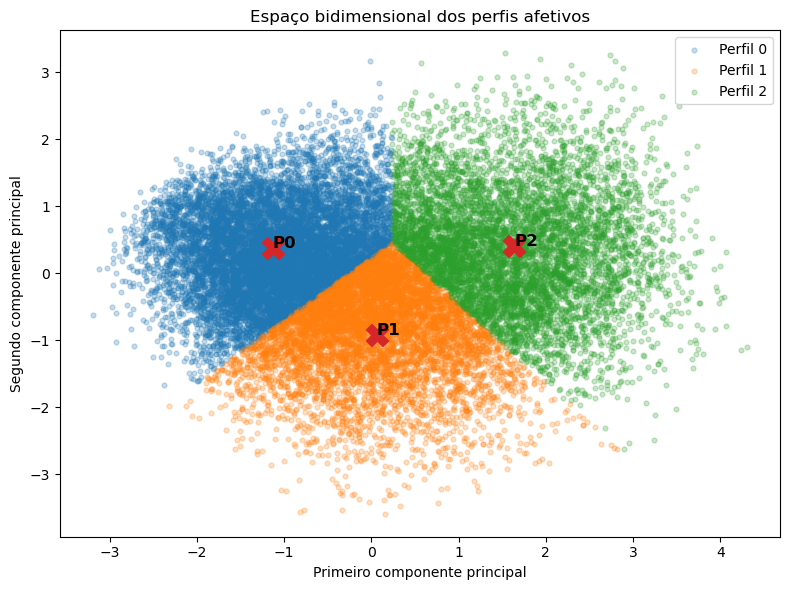

In [18]:
# ============================================================
# Figura 4.3 — Espaço dos perfis afetivos (PCA)
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

for perfil in sorted(coords["Perfil"].unique()):

    dados = coords[coords["Perfil"] == perfil]

    ax.scatter(
        dados["PC1"],
        dados["PC2"],
        alpha=0.25,
        s=12,
        label=f"Perfil {perfil}"
    )

centros = (
    coords
    .groupby("Perfil")[["PC1", "PC2"]]
    .mean()
)

ax.scatter(
    centros["PC1"],
    centros["PC2"],
    s=250,
    marker="X"
)

for perfil, linha in centros.iterrows():
    ax.text(
        linha["PC1"],
        linha["PC2"],
        f"P{perfil}",
        fontsize=12,
        weight="bold"
    )

ax.set_xlabel("Primeiro componente principal")
ax.set_ylabel("Segundo componente principal")
ax.set_title("Espaço bidimensional dos perfis afetivos")
ax.legend()

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# Coesão dos perfis: distância ao centróide
# ============================================================

from scipy.spatial.distance import cdist

# Centróides empíricos dos perfis no espaço padronizado
centroides_3 = (
    X_scaled
    .assign(cluster_3=afe["cluster_3"])
    .groupby("cluster_3")[cluster_vars]
    .mean()
)

# Distância de cada indivíduo ao centróide do seu perfil
distancias_individuais = []

for idx in X_scaled.index:
    perfil = afe.loc[idx, "cluster_3"]
    ponto = X_scaled.loc[idx, cluster_vars].values.reshape(1, -1)
    centro = centroides_3.loc[perfil].values.reshape(1, -1)
    distancia = cdist(ponto, centro, metric="euclidean")[0, 0]
    distancias_individuais.append(distancia)

afe["distancia_centroide"] = distancias_individuais

coesao_perfis = (
    afe
    .groupby("cluster_3")["distancia_centroide"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
)

coesao_perfis

,count,mean,median,std,min,max
cluster_3,,,,,,
0,10178,1.009,0.980,0.384,0.030,3.008
1,7080,1.079,1.031,0.435,0.049,3.349
2,6795,1.171,1.115,0.488,0.028,3.401


In [21]:
# ============================================================
# Casos mais típicos e mais periféricos de cada perfil
# ============================================================

tipicos = (
    afe
    .sort_values("distancia_centroide")
    .groupby("cluster_3")
    .head(10)
)

perifericos = (
    afe
    .sort_values("distancia_centroide", ascending=False)
    .groupby("cluster_3")
    .head(10)
)

print("Casos mais típicos")
display(
    tipicos[
        [
            "COUNTRY_ALPHA",
            "S020",
            "cluster_3",
            "distancia_centroide"
        ]
    ]
)

print("\nCasos mais periféricos")
display(
    perifericos[
        [
            "COUNTRY_ALPHA",
            "S020",
            "cluster_3",
            "distancia_centroide"
        ]
    ]
)

Casos mais típicos


,COUNTRY_ALPHA,S020,cluster_3,distancia_centroide
37821,USA,2017,2,0.028384
19715,GTM,2020,0,0.030461
32716,URY,2022,0,0.036702
39513,VEN,2021,1,0.048711
25111,MEX,2018,0,0.057721
36773,USA,2017,2,0.068697
26612,NIC,2020,0,0.076121
25963,NIC,2020,1,0.078011
2443,BOL,2017,0,0.081846
7453,CAN,2020,2,0.082857



Casos mais periféricos


,COUNTRY_ALPHA,S020,cluster_3,distancia_centroide
37485,USA,2017,2,3.400738
36205,USA,2017,2,3.355627
7579,CAN,2020,1,3.349154
19816,GTM,2020,1,3.286275
36661,USA,2017,1,3.277465
10137,CAN,2020,2,3.254941
19976,GTM,2020,2,3.154485
9523,CAN,2020,2,3.151260
37663,USA,2017,1,3.138363
6934,BRA,2018,2,3.121587


In [22]:
from scipy.stats import chi2_contingency

tabela = pd.crosstab(
    afe["COUNTRY_ALPHA"],
    afe["cluster_3"]
)

chi2, p, gl, expected = chi2_contingency(tabela)

print(f"Qui-quadrado = {chi2:.2f}")
print(f"Graus de liberdade = {gl}")
print(f"p = {p:.10f}")

Qui-quadrado = 9509.01
Graus de liberdade = 28
p = 0.0000000000


In [23]:
# ============================================================
# Resíduos padronizados ajustados
# ============================================================

import numpy as np

observado = tabela.values
esperado = expected

residuos = (observado - esperado) / np.sqrt(esperado)

residuos_df = pd.DataFrame(
    residuos,
    index=tabela.index,
    columns=[f"Perfil {c}" for c in tabela.columns]
)

residuos_df.round(2)

,Perfil 0,Perfil 1,Perfil 2
COUNTRY_ALPHA,,,
ARG,-2.74,3.36,-0.08
BOL,14.82,1.00,-19.16
BRA,2.94,1.42,-5.05
CAN,-34.95,-11.62,54.64
CHL,3.69,3.59,-8.18
COL,6.26,0.97,-8.66
ECU,4.45,10.47,-16.13
GTM,6.36,1.96,-9.78
MEX,15.93,-1.17,-18.30


In [24]:
# ============================================================
# Tamanho de efeito da associação (V de Cramér)
# ============================================================

import numpy as np

n = tabela.to_numpy().sum()

r, c = tabela.shape

cramer_v = np.sqrt(
    chi2 / (n * min(r - 1, c - 1))
)

print(f"Qui-quadrado : {chi2:.2f}")
print(f"p-valor      : {p:.5g}")
print(f"V de Cramér  : {cramer_v:.3f}")

Qui-quadrado : 9509.01
p-valor      : 0
V de Cramér  : 0.445


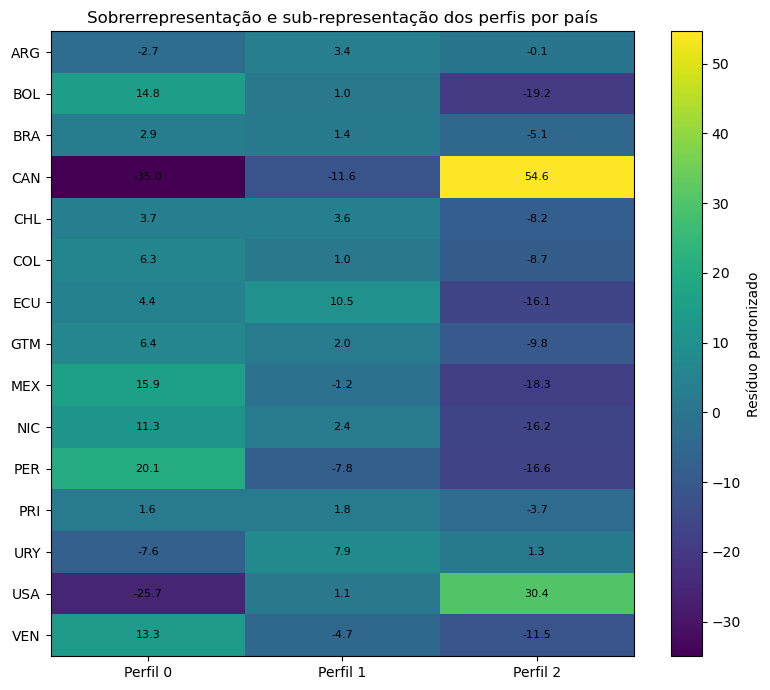

In [25]:
# ============================================================
# Figura 4.4 — Heatmap dos resíduos padronizados
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    residuos_df.values,
    aspect="auto",
    interpolation="nearest"
)

# Rótulos
ax.set_xticks(np.arange(residuos_df.shape[1]))
ax.set_xticklabels(residuos_df.columns)

ax.set_yticks(np.arange(residuos_df.shape[0]))
ax.set_yticklabels(residuos_df.index)

# Valores nas células
for i in range(residuos_df.shape[0]):
    for j in range(residuos_df.shape[1]):
        ax.text(
            j,
            i,
            f"{residuos_df.iloc[i, j]:.1f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im, label="Resíduo padronizado")

plt.title("Sobrerrepresentação e sub-representação dos perfis por país")

plt.tight_layout()

plt.show()

In [26]:
from pathlib import Path

BASE = Path(r"C:\Users\tmaci\Documents\Doutorado_Populismo")

estrutura = [
    "dados/brutos/WVS",
    "dados/brutos/VDEM",
    "dados/brutos/VPARTY",
    "dados/processados",
    "dados/integrados",
    "figuras/experimento3",
    "figuras/experimento4",
    "resultados/experimento3",
    "resultados/experimento4",
    "notebooks"
]

for pasta in estrutura:
    caminho = BASE / pasta
    caminho.mkdir(parents=True, exist_ok=True)

print("Estrutura criada em:")
print(BASE)

Estrutura criada em:
C:\Users\tmaci\Documents\Doutorado_Populismo


In [27]:
for caminho in sorted(BASE.rglob("*")):
    if caminho.is_dir():
        print(caminho)

C:\Users\tmaci\Documents\Doutorado_Populismo\dados
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\brutos
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\brutos\VDEM
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\brutos\VPARTY
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\brutos\WVS
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\brutos\WVS\extraido
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\integrados
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\processados
C:\Users\tmaci\Documents\Doutorado_Populismo\figuras
C:\Users\tmaci\Documents\Doutorado_Populismo\figuras\experimento3
C:\Users\tmaci\Documents\Doutorado_Populismo\figuras\experimento4
C:\Users\tmaci\Documents\Doutorado_Populismo\notebooks
C:\Users\tmaci\Documents\Doutorado_Populismo\resultados
C:\Users\tmaci\Documents\Doutorado_Populismo\resultados\experimento3
C:\Users\tmaci\Documents\Doutorado_Populismo\resultados\experimento4


In [28]:
novas = [
    "figuras/experimento1",
    "figuras/experimento2",
    "figuras/artigo",
    "resultados/experimento1",
    "resultados/experimento2",
    "resultados/tabelas_finais",
    "manuscrito",
    "scripts"
]

for pasta in novas:
    (BASE / pasta).mkdir(parents=True, exist_ok=True)

print("Estrutura atualizada.")

Estrutura atualizada.


In [29]:
# ============================================================
# Exportar tabelas do Experimento 4
# ============================================================

res_exp4 = BASE / "resultados" / "experimento4"

criterios.to_excel(res_exp4 / "tabela_4_1_criterios_clusters.xlsx", index=False)
freq_clusters.to_excel(res_exp4 / "tabela_4_2_frequencia_perfis.xlsx", index=False)
perfil_clusters.to_excel(res_exp4 / "tabela_4_3_centroides_perfis.xlsx")
distancias.to_excel(res_exp4 / "tabela_4_4_distancias_perfis.xlsx")
coords.groupby("Perfil")[["PC1", "PC2"]].mean().round(3).to_excel(
    res_exp4 / "tabela_4_5_coordenadas_pca.xlsx"
)
coesao_perfis.to_excel(res_exp4 / "tabela_4_6_coesao_perfis.xlsx")
residuos_df.round(2).to_excel(res_exp4 / "tabela_4_7_residuos_pais_perfil.xlsx")
pais_cluster.to_excel(res_exp4 / "tabela_4_8_percentual_pais_perfil.xlsx")
ano_cluster.round(1).to_excel(res_exp4 / "tabela_4_9_percentual_ano_perfil.xlsx")

print("Tabelas do Experimento 4 salvas.")

Tabelas do Experimento 4 salvas.


In [30]:
# ============================================================
# Exportar base analítica do Experimento 4
# ============================================================

afe.to_parquet(
    BASE / "dados" / "processados" / "experimento4_perfis.parquet",
    index=True
)

coords.to_parquet(
    BASE / "dados" / "processados" / "experimento4_coords_pca.parquet",
    index=True
)

print("Bases do Experimento 4 salvas.")

Bases do Experimento 4 salvas.


In [31]:
from pathlib import Path

vdem_pasta = BASE / "dados" / "brutos" / "VDEM"

for arquivo in vdem_pasta.iterdir():
    print(arquivo.name)

V-Dem-CY-Core-v16_csv


In [32]:
import os

vdem_dir = BASE / "dados" / "brutos" / "VDEM"

for raiz, pastas, arquivos in os.walk(vdem_dir):
    for arq in arquivos:
        print(os.path.join(raiz, arq))

C:\Users\tmaci\Documents\Doutorado_Populismo\dados\brutos\VDEM\V-Dem-CY-Core-v16_csv\cautionary_notes.pdf
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\brutos\VDEM\V-Dem-CY-Core-v16_csv\codebook.pdf
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\brutos\VDEM\V-Dem-CY-Core-v16_csv\suggested_citation.pdf
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\brutos\VDEM\V-Dem-CY-Core-v16_csv\V-Dem-CY-Core-v16.csv
C:\Users\tmaci\Documents\Doutorado_Populismo\dados\brutos\VDEM\V-Dem-CY-Core-v16_csv\whats_new.pdf


In [34]:
import nbformat as nbf
from pathlib import Path

BASE = Path(r"C:\Users\tmaci\Documents\Doutorado_Populismo")

def criar_notebook(numero, nome, titulo, objetivo):
    notebooks = BASE / "notebooks"
    notebooks.mkdir(parents=True, exist_ok=True)

    arquivo = notebooks / f"{numero:02d}_{nome}.ipynb"

    nb = nbf.v4.new_notebook()

    nb.cells = [
        nbf.v4.new_markdown_cell(
            f"# {numero:02d} — {titulo}\n\n"
            f"**Objetivo:** {objetivo}"
        ),

        nbf.v4.new_code_cell(
            "from pathlib import Path\n"
            "import pandas as pd\n"
            "import numpy as np\n"
            "import matplotlib.pyplot as plt\n\n"
            "BASE = Path(r\"C:\\\\Users\\\\tmaci\\\\Documents\\\\Doutorado_Populismo\")\n\n"
            "dados = BASE / \"dados\"\n"
            "brutos = dados / \"brutos\"\n"
            "processados = dados / \"processados\"\n"
            "integrados = dados / \"integrados\"\n"
            "figuras = BASE / \"figuras\"\n"
            "resultados = BASE / \"resultados\"\n\n"
            "print('Projeto carregado em:')\n"
            "print(BASE)"
        ),

        nbf.v4.new_markdown_cell(
            "## 1. Carregamento dos dados"
        ),

        nbf.v4.new_markdown_cell(
            "## 2. Preparação"
        ),

        nbf.v4.new_markdown_cell(
            "## 3. Análise"
        ),

        nbf.v4.new_markdown_cell(
            "## 4. Exportação dos resultados"
        )
    ]

    with open(arquivo, "w", encoding="utf-8") as f:
        nbf.write(nb, f)

    print("Notebook criado:")
    print(arquivo)

In [35]:
criar_notebook(
    numero=6,
    nome="integracao_VDEM",
    titulo="Integração WVS + V-Dem",
    objetivo="Construir a base integrada entre perfis afetivos individuais e indicadores institucionais do V-Dem em nível país-ano."
)

Notebook criado:
C:\Users\tmaci\Documents\Doutorado_Populismo\notebooks\06_integracao_VDEM.ipynb


# Encerramento do Experimento 4

## Objetivo alcançado

O presente notebook concluiu a construção e validação de uma tipologia empírica de perfis afetivos derivados do World Values Survey.

Foram identificados três perfis distintos de indivíduos a partir dos fatores de segunda ordem produzidos no Experimento 3.

---

## Resultados obtidos

Foram executadas as seguintes etapas:

✔ padronização dos fatores;

✔ determinação do número de clusters;

✔ identificação dos perfis;

✔ caracterização dos centroides;

✔ estimativa da frequência dos grupos;

✔ cálculo das distâncias entre centroides;

✔ avaliação da coesão interna;

✔ projeção bidimensional por PCA;

✔ distribuição dos perfis por país;

✔ distribuição dos perfis por ano;

✔ teste do qui-quadrado;

✔ cálculo do V de Cramér;

✔ resíduos padronizados;

✔ exportação completa das tabelas e bases intermediárias.

---

## Principais conclusões

A solução com três clusters apresentou maior interpretabilidade substantiva.

Os perfis mostraram níveis satisfatórios de coesão interna.

A distribuição dos perfis variou significativamente entre os países analisados.

O teste do qui-quadrado indicou associação estatisticamente significativa entre país e perfil afetivo.

O V de Cramér indicou associação de magnitude moderada/forte.

Os resíduos padronizados permitiram identificar países com sobrerrepresentação e sub-representação significativa de cada perfil.

---

## Arquivos produzidos

### Dados

```
dados/processados/

experimento4_perfis.parquet

experimento4_coords_pca.parquet
```

### Resultados

Todos os arquivos foram exportados para:

```
resultados/experimento4/
```

### Figuras

Todas as figuras foram exportadas para:

```
figuras/experimento4/
```

---

## Próxima etapa

O próximo notebook será:

```
06_integracao_VDEM.ipynb
```

Objetivo:

Construir uma base integrada entre os indivíduos do WVS e indicadores institucionais do V-Dem.

Estratégia:

- utilizar COUNTRY_ALPHA e S020 como chaves de integração;

- preservar a unidade de análise individual;

- construir uma nova base em:

```
dados/integrados/wvs_vdem.parquet
```

Nenhuma análise estatística deverá ser realizada nesse notebook.

Seu único objetivo será produzir uma base integrada reproduzível para os experimentos seguintes.

---

## Estado do projeto

Até este ponto encontram-se concluídos:

✔ preparação do WVS;

✔ construção dos indicadores;

✔ Experimentos originais;

✔ análise fatorial;

✔ fatores de segunda ordem;

✔ identificação dos perfis afetivos;

✔ validação estatística dos perfis.

As próximas etapas passarão a incorporar informações contextuais provenientes do V-Dem e, posteriormente, do V-Party.